<a href="https://colab.research.google.com/github/DanThomas1994/Python-Projects/blob/main/Day_73_Programming_Languages_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Get the Data

Either use the provided .csv file or (optionally) get fresh (the freshest?) data from running an SQL query on StackExchange:

Follow this link to run the query from [StackExchange](https://data.stackexchange.com/stackoverflow/query/675441/popular-programming-languages-per-over-time-eversql-com) to get your own .csv file

<code>
select dateadd(month, datediff(month, 0, q.CreationDate), 0) m, TagName, count(*)
from PostTags pt
join Posts q on q.Id=pt.PostId
join Tags t on t.Id=pt.TagId
where TagName in ('java','c','c++','python','c#','javascript','assembly','php','perl','ruby','visual basic','swift','r','object-c','scratch','go','swift','delphi')
and q.CreationDate < dateadd(month, datediff(month, 0, getdate()), 0)
group by dateadd(month, datediff(month, 0, q.CreationDate), 0), TagName
order by dateadd(month, datediff(month, 0, q.CreationDate), 0)
</code>

## Import Statements

In [94]:
import pandas as pd

## Data Exploration

**Challenge**: Read the .csv file and store it in a Pandas dataframe

In [95]:
df = pd.read_csv("QueryResults.csv",names=['DATE','TAG','POSTS'],header=0) # Setting the header to 0 enables the column titles
# to be changed.
print(df) # Print the whole dataframe.
# print(df.TagName) # Print the column with title 'TagName'.
# print(df.m) # Print the column with title 'm'.

                     DATE         TAG  POSTS
0     2008-07-01 00:00:00          c#      3
1     2008-08-01 00:00:00    assembly      8
2     2008-08-01 00:00:00  javascript    162
3     2008-08-01 00:00:00           c     85
4     2008-08-01 00:00:00      python    124
...                   ...         ...    ...
1986  2020-07-01 00:00:00           r   5694
1987  2020-07-01 00:00:00          go    743
1988  2020-07-01 00:00:00        ruby    775
1989  2020-07-01 00:00:00        perl    182
1990  2020-07-01 00:00:00       swift   3607

[1991 rows x 3 columns]


**Challenge**: Examine the first 5 rows and the last 5 rows of the of the dataframe

In [96]:
# print(df[0:5])
print(df.head())
# print(df[1986:])
print(df.tail())

                  DATE         TAG  POSTS
0  2008-07-01 00:00:00          c#      3
1  2008-08-01 00:00:00    assembly      8
2  2008-08-01 00:00:00  javascript    162
3  2008-08-01 00:00:00           c     85
4  2008-08-01 00:00:00      python    124
                     DATE    TAG  POSTS
1986  2020-07-01 00:00:00      r   5694
1987  2020-07-01 00:00:00     go    743
1988  2020-07-01 00:00:00   ruby    775
1989  2020-07-01 00:00:00   perl    182
1990  2020-07-01 00:00:00  swift   3607


**Challenge:** Check how many rows and how many columns there are.
What are the dimensions of the dataframe?

In [97]:
print(len(df)) # Print the number of rows.
print(len(df.columns)) # Print the number of columns.
# Alternatively, use shape:
print(df.shape)

1991
3
(1991, 3)


**Challenge**: Count the number of entries in each column of the dataframe

In [98]:
# print(df.iloc[_]
# print(df.iloc[_]['POSTS'])

# df['POSTS'] = int(df['POSTS'])
# print(df.iloc[0]['POSTS'])
# Create a new dataframe with only the POSTS and TAG columns:
df2 = df[['POSTS','TAG']]
print(df2)
check = df2.groupby('TAG').sum() # This groups the languages according to their name and sums the number of posts.
print(check)

languages = [] # Create a blank list to store the different languages in.
for language in df['TAG']: # Go through the whole languages column.
  if language not in languages: # If a language isn't already in the languages list, add it to the list.
    languages.append(language)
# print(languages)

      POSTS         TAG
0         3          c#
1         8    assembly
2       162  javascript
3        85           c
4       124      python
...     ...         ...
1986   5694           r
1987    743          go
1988    775        ruby
1989    182        perl
1990   3607       swift

[1991 rows x 2 columns]
              POSTS
TAG                
assembly      34852
c            336042
c#          1423530
c++          684210
delphi        46212
go            47499
java        1696403
javascript  2056510
perl          65286
php         1361988
python      1496210
r            356799
ruby         214582
swift        273055


**Challenge**: Calculate the total number of post per language.
Which Programming language has had the highest total number of posts of all time?

In [99]:
# Alternative method:
# Firstly ensure the number of posts in each row is an integer:
# for row in range(0,len(df)):
#   df.iloc[row]['POSTS'] = int(df.iloc[row]['POSTS']) # Use int to get the number as an integer value instead of np.int64.

posts_alt_method = print(df.groupby('TAG').count())
print(posts_alt_method)
print(df)

# Create a dictionary to store the language:number of posts data in:
posts = {} # Create a blank dictionary.
for language in languages:
  posts[language] = 0
# print(posts)

# Get the number of posts associated with each language:
for row in range(0,len(df)):
  for language in languages:
    if df.iloc[row]['TAG'] == language:
      posts[language] += df.iloc[row]['POSTS'] # Use int to get the number as an integer value instead of np.int64.
# print(posts)

# Find which language has the most number of posts:
# Find the key with the maximum value in a dictionary

def get_key_with_max_value(data):
    """
    Returns the key with the highest value in the dictionary.
    Handles empty dictionaries safely.
    """
    if not isinstance(data, dict):
        raise TypeError("Input must be a dictionary.")
    if not data:
        raise ValueError("Dictionary is empty.")

    # max() finds the key whose value is the largest
    return max(data, key=data.get)

max_value = get_key_with_max_value(posts)
print(max_value)

post_number = []
for language in posts:
  # print(posts[language])
  post_number.append(posts[language])
print(post_number)
print(posts)
# print(posts[language])
# max_value = max(posts[language])
# print(max_value)

            DATE  POSTS
TAG                    
assembly     144    144
c            144    144
c#           145    145
c++          144    144
delphi       144    144
go           129    129
java         144    144
javascript   144    144
perl         144    144
php          144    144
python       144    144
r            142    142
ruby         144    144
swift        135    135
None
                     DATE         TAG  POSTS
0     2008-07-01 00:00:00          c#      3
1     2008-08-01 00:00:00    assembly      8
2     2008-08-01 00:00:00  javascript    162
3     2008-08-01 00:00:00           c     85
4     2008-08-01 00:00:00      python    124
...                   ...         ...    ...
1986  2020-07-01 00:00:00           r   5694
1987  2020-07-01 00:00:00          go    743
1988  2020-07-01 00:00:00        ruby    775
1989  2020-07-01 00:00:00        perl    182
1990  2020-07-01 00:00:00       swift   3607

[1991 rows x 3 columns]
javascript
[np.int64(1423530), np.int64(34852)

Some languages are older (e.g., C) and other languages are newer (e.g., Swift). The dataset starts in September 2008.

**Challenge**: How many months of data exist per language? Which language had the fewest months with an entry?


In [100]:
print(df)

dates = {} # Create a blank dictionary.
for language in languages:
  dates[language] = 0
print(dates)

# Get the number of months associated with each language:
for row in range(0,len(df)): # Go through each row in the dataframe.
  for language in languages: # For each row in the dataframe, loop through all the languages, looking for if the language
  # in the dataframe row matches the one in the languages list.
    if df.iloc[row]['TAG'] == language:
      dates[language] += 1
print(dates)


                     DATE         TAG  POSTS
0     2008-07-01 00:00:00          c#      3
1     2008-08-01 00:00:00    assembly      8
2     2008-08-01 00:00:00  javascript    162
3     2008-08-01 00:00:00           c     85
4     2008-08-01 00:00:00      python    124
...                   ...         ...    ...
1986  2020-07-01 00:00:00           r   5694
1987  2020-07-01 00:00:00          go    743
1988  2020-07-01 00:00:00        ruby    775
1989  2020-07-01 00:00:00        perl    182
1990  2020-07-01 00:00:00       swift   3607

[1991 rows x 3 columns]
{'c#': 0, 'assembly': 0, 'javascript': 0, 'c': 0, 'python': 0, 'perl': 0, 'c++': 0, 'java': 0, 'delphi': 0, 'ruby': 0, 'php': 0, 'r': 0, 'swift': 0, 'go': 0}
{'c#': 145, 'assembly': 144, 'javascript': 144, 'c': 144, 'python': 144, 'perl': 144, 'c++': 144, 'java': 144, 'delphi': 144, 'ruby': 144, 'php': 144, 'r': 142, 'swift': 135, 'go': 129}


## Data Cleaning

Let's fix the date format to make it more readable. We need to use Pandas to change format from a string of "2008-07-01 00:00:00" to a datetime object with the format of "2008-07-01"

In [101]:
# Convert the 'DATE' column (currently all strings) to datetime objects (this ensures Pandas recognizes them as dates):
try:
    df['DATE'] = pd.to_datetime(df['DATE'], errors='raise')  # errors='raise' will throw if invalid
except Exception as e:
    print(f"Error converting to datetime: {e}")
    exit(1)

# Step 2: Change the display format (without changing the underlying datetime type)
# Use dt.strftime to format as desired
df['DATE_formatted'] = df['DATE'].dt.strftime('%Y-%m-%d')  # e.g., 26-01-2016
print(df)

           DATE         TAG  POSTS DATE_formatted
0    2008-07-01          c#      3     2008-07-01
1    2008-08-01    assembly      8     2008-08-01
2    2008-08-01  javascript    162     2008-08-01
3    2008-08-01           c     85     2008-08-01
4    2008-08-01      python    124     2008-08-01
...         ...         ...    ...            ...
1986 2020-07-01           r   5694     2020-07-01
1987 2020-07-01          go    743     2020-07-01
1988 2020-07-01        ruby    775     2020-07-01
1989 2020-07-01        perl    182     2020-07-01
1990 2020-07-01       swift   3607     2020-07-01

[1991 rows x 4 columns]


## Data Manipulation



**Challenge**: What are the dimensions of our new dataframe? How many rows and columns does it have? Print out the column names and print out the first 5 rows of the dataframe.

**Challenge**: Count the number of entries per programming language. Why might the number of entries be different?

## Data Visualisaton with with Matplotlib


**Challenge**: Use the [matplotlib documentation](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.plot.html#matplotlib.pyplot.plot) to plot a single programming language (e.g., java) on a chart.

In [102]:
import matplotlib.pyplot as plt

['2008-08-01', '2008-09-01', '2008-10-01', '2008-11-01', '2008-12-01', '2009-01-01', '2009-02-01', '2009-03-01', '2009-04-01', '2009-05-01', '2009-06-01', '2009-07-01', '2009-08-01', '2009-09-01', '2009-10-01', '2009-11-01', '2009-12-01', '2010-01-01', '2010-02-01', '2010-03-01', '2010-04-01', '2010-05-01', '2010-06-01', '2010-07-01', '2010-08-01', '2010-09-01', '2010-10-01', '2010-11-01', '2010-12-01', '2011-01-01', '2011-02-01', '2011-03-01', '2011-04-01', '2011-05-01', '2011-06-01', '2011-07-01', '2011-08-01', '2011-09-01', '2011-10-01', '2011-11-01', '2011-12-01', '2012-01-01', '2012-02-01', '2012-03-01', '2012-04-01', '2012-05-01', '2012-06-01', '2012-07-01', '2012-08-01', '2012-09-01', '2012-10-01', '2012-11-01', '2012-12-01', '2013-01-01', '2013-02-01', '2013-03-01', '2013-04-01', '2013-05-01', '2013-06-01', '2013-07-01', '2013-08-01', '2013-09-01', '2013-10-01', '2013-11-01', '2013-12-01', '2014-01-01', '2014-02-01', '2014-03-01', '2014-04-01', '2014-05-01', '2014-06-01', '2014

([<matplotlib.axis.XTick at 0x791ae96cc770>,
 [Text(0.0, 0, '2008-08-01'),
  Text(35.0, 0, '2011-07-01'),
  Text(70.0, 0, '2014-06-01'),
  Text(105.0, 0, '2017-05-01'),
  Text(140.0, 0, '2020-04-01')])

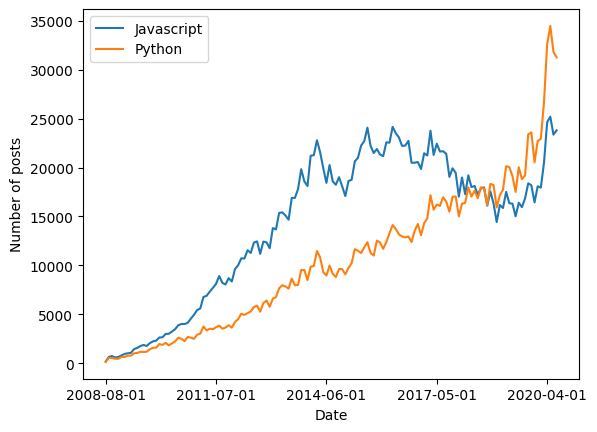

In [103]:
# print(df['DATE_formatted'])
x_javascript = []
y_javascript = []
# print(df.iloc[0]['TAG'])
for row in range(0,len(df)):
  if df.iloc[row]['TAG'] == 'javascript':
    x_javascript.append(df.iloc[row]['DATE_formatted'])
    y_javascript.append(int(df.iloc[row]['POSTS']))
print(x_javascript)
print(y_javascript)

plt.plot(x_javascript,y_javascript,label='Javascript')

x_python = []
y_python = []
# print(df.iloc[0]['TAG'])
for row in range(0,len(df)):
  if df.iloc[row]['TAG'] == 'python':
    x_python.append(df.iloc[row]['DATE_formatted'])
    y_python.append(int(df.iloc[row]['POSTS']))
print(x_python)
print(y_python)

plt.plot(x_python,y_python,label='Python')
plt.xlabel('Date')
plt.ylabel('Number of posts')
plt.legend()

plt.xticks(x_python[::35])

**Challenge**: Show two line (e.g. for Java and Python) on the same chart.

# Smoothing out Time Series Data

Time series data can be quite noisy, with a lot of up and down spikes. To better see a trend we can plot an average of, say 6 or 12 observations. This is called the rolling mean. We calculate the average in a window of time and move it forward by one overservation. Pandas has two handy methods already built in to work this out: [rolling()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rolling.html) and [mean()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.core.window.rolling.Rolling.mean.html).

0               NaN
1               NaN
2               NaN
3               NaN
4               NaN
           ...     
139    23304.000000
140    24838.500000
141    26653.166667
142    28535.000000
143    29962.000000
Length: 144, dtype: float64


([<matplotlib.axis.XTick at 0x791ae954c110>,
 [Text(0.0, 0, '2008-08-01'),
  Text(35.0, 0, '2011-07-01'),
  Text(70.0, 0, '2014-06-01'),
  Text(105.0, 0, '2017-05-01'),
  Text(140.0, 0, '2020-04-01')])

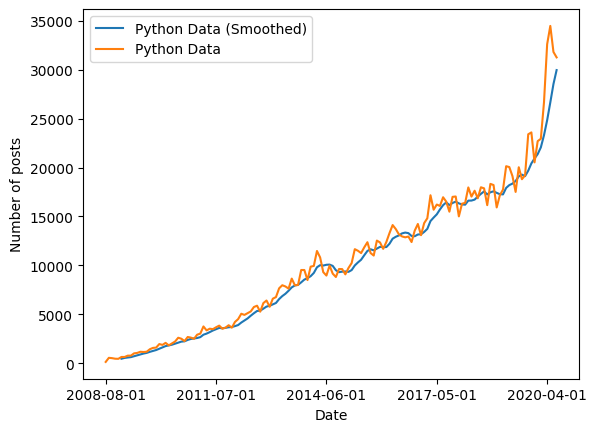

In [104]:
observations = 6
python_data_smoothed = pd.Series(y_python).rolling(window=observations).mean() # Smooth the data by calculating a rolling mean:
# find the average of the 6 previous data points at each time and plot the average for each time.
print(python_data_smoothed)
plt.plot(x_python,python_data_smoothed,label='Python Data (Smoothed)')
plt.plot(x_python,y_python,label='Python Data')
plt.xlabel('Date')
plt.ylabel('Number of posts')
plt.legend()
plt.xticks(x_python[::35])

# print(len(x_python))
